In [1]:
import pandas as pd
from scipy import stats
import numpy as np
import math
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Lab_8_Section_B_marks_dataset.csv")
marks = df['Marks']

## Custom Implementation

In [3]:
z_test_data = df['Marks'].sample(50)
t_test_data = df['Marks'].sample(25)

st = marks.sample(n=25, random_state=42)
sz = marks.sample(n=50, random_state=42)

pop_mean = 70
pop_std = 15

## Z-Test

In [4]:
z_mean = sz.mean()
nz = len(sz)

z = (z_mean-pop_mean)/(pop_std/np.sqrt(nz))
z_p = 2*(1-stats.norm.cdf(abs(z)))

print("z score:", z)
print("p-value of z score:", z_p)
print('\n')

significance_levels = [0.05, 0.10, 0.15]

for alpha in significance_levels:
    if z_p < alpha:
        print("p value: ", z_p, "alpha: ", alpha)
        print("Reject the null hypothesis. \n")
    else:
        print("p value: ", z_p, "alpha: ", alpha)
        print("Fail to reject the null hypothesis. \n")

z score: 0.5185449728701322
p-value of z score: 0.6040780906072447


p value:  0.6040780906072447 alpha:  0.05
Fail to reject the null hypothesis. 

p value:  0.6040780906072447 alpha:  0.1
Fail to reject the null hypothesis. 

p value:  0.6040780906072447 alpha:  0.15
Fail to reject the null hypothesis. 



## T-Test

In [5]:
t_mean = st.mean()
sample_std = st.std(ddof=1)
nt = len(st)

t = (t_mean-pop_mean)/(sample_std/np.sqrt(nt))
t_p = 2*(1-stats.t.cdf(abs(t), df=nt-1))

print("t statistic: ", t)
print("p-value of t-statistic", t_p)
print('\n')

for alpha in significance_levels:
    if t_p < alpha:
        print("p value: ", t_p, "alpha: ", alpha)
        print("Reject the null hypothesis. \n")
    else:
        print("p value: ", t_p, "alpha: ", alpha)
        print("Fail to reject the null hypothesis. \n")

t statistic:  1.3571420086731312
p-value of t-statistic 0.18736323269240795


p value:  0.18736323269240795 alpha:  0.05
Fail to reject the null hypothesis. 

p value:  0.18736323269240795 alpha:  0.1
Fail to reject the null hypothesis. 

p value:  0.18736323269240795 alpha:  0.15
Fail to reject the null hypothesis. 



## Visualization

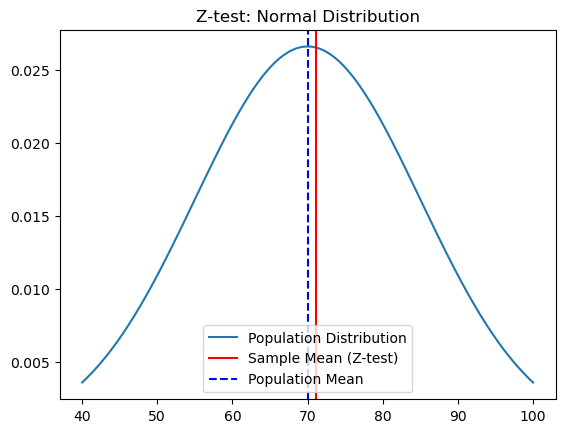

NameError: name 'popmean' is not defined

In [6]:
x = np.linspace(40, 100, 1000)
plt.plot(x, stats.norm.pdf(x, pop_mean, pop_std), label='Population Distribution')
plt.axvline(z_mean, color='red', label='Sample Mean (Z-test)')
plt.axvline(pop_mean, color='blue', linestyle='--', label='Population Mean')
plt.title("Z-test: Normal Distribution")
plt.legend()
plt.show()

xt=np.linspace(40, 100, 100)
plt.plot(xt, stats.t.pdf(xt, df=nt-1, loc=popmean, scale=sampstd/np.sqrt(nt)), label='Sample T-distribution')
plt.axvline(t_mean, color='red', label='Sample Mean (T-test)')
plt.axvline(pop_mean, color='blue', linestyle='--', label='Population Mean')
plt.title("T-test: T Distribution")
plt.legend()
plt.show()

## Inbuilt Functions

In [ ]:
st2=marks.sample(n=25)
sz2=marks.sample(n=50)

## T-Test

In [ ]:
t2, p_t2 = stats.ttest_1samp(st2, pop_mean)

for alpha in significance_levels:
    if p_t2 < alpha:
        print("p value: ", p_t2, "alpha: ", alpha)
        print("Reject the null hypothesis. \n")
    else:
        print("p value: ", p_t2, "alpha: ", alpha)
        print("Fail to reject the null hypothesis. \n")


## Z-Test

In [ ]:
z_mean2 = sz2.mean()
z2 = (z_mean2-pop_mean)/(pop_std/np.sqrt(len(sz2)))
p_z2 = 2*(1-stats.norm.cdf(abs(z2)))

for alpha in significance_levels:
    if p_z2 < alpha:
        print("p value: ", p_z2, "alpha: ", alpha)
        print("Reject the null hypothesis. \n")
    else:
        print("p value: ", p_z2, "alpha: ", alpha)
        print("Fail to reject the null hypothesis. \n")

## Visualization

In [ ]:
x2 = np.linspace(40, 100, 100)
plt.plot(x2, stats.norm.pdf(x2, pop_mean, pop_std), label='Population Distribution')
plt.axvline(z_mean2, color='red', label='Sample Mean (Z-test)')
plt.axvline(pop_mean, color='blue', linestyle='--', label='Population Mean')
plt.title("Z-test Normal Distribution (Random Sampling)")
plt.legend()
plt.show()

samp_tmean2=st2.mean()
samp_tstd2=st2.std(ddof=1)
nt2=len(st2)

xt2=np.linspace(40, 100, 100)
plt.plot(xt2, stats.t.pdf(xt2, df=nt2-1, loc=pop_mean, scale=samp_tstd2 / np.sqrt(nt2)), label='Sample T-distribution')
plt.axvline(samp_tmean2, color='red', label='Sample Mean (T-test)')
plt.axvline(pop_mean, color='blue', linestyle='--', label='Population Mean')
plt.title("T-test T-distribution (Random Sampling)")
plt.legend()
plt.show()